# Seasonality Analysis

## Import data

In here we are importing the data set that is saved in the computer in a folder named "clean_data", after that we created the variable "names" that contains the individual names of each branch to access it easier later on; at the end the program reads all the CSV's that contain similar names so the branches that have the "-2" are taken into account.

In [2]:
import os
import pandas as pd 

folder = "clean_data"
names = ["Carreta", "Zambrano", "Credi-Club", "Kavia", "Nativa", "QIN", "Punto-Valle"]

csv_files = [entry.name for entry in os.scandir(folder) if entry.is_file() and entry.name.lower().endswith('.csv')]

dfs_by_name = {}

for location in names:
    matched = [fn for fn in csv_files if location in fn]

    df_list =[pd.read_csv(os.path.join(folder, fn), low_memory=False, index_col=0) for fn in matched]

    dfs_by_name[location] = pd.concat(df_list, ignore_index=True)

Defining the variables 

In [3]:
carreta = dfs_by_name["Carreta"]
crediclub = dfs_by_name["Credi-Club"]
kavia = dfs_by_name["Kavia"]
nativa = dfs_by_name["Nativa"]
puntovalle = dfs_by_name["Punto-Valle"]
qin = dfs_by_name["QIN"]
zambrano = dfs_by_name["Zambrano"]

Chechking if the dataset was defined correctly 

In [4]:
carreta.columns

Index(['sucursal', 'operating_date', 'day_name', 'closing_time',
       'captured_time', 'week_number', 'pdv_txn_id', 'order_id', 'order_type',
       'order_subtype', 'table_number', 'party_size', 'server', 'terminal',
       'capture_terminal', 'action', 'item', 'modifier', 'group_type', 'group',
       'description', 'is_modifier', 'quantity', 'unit_price',
       'unit_price_with_mods', 'cost_actual', 'cost_with_mods', 'cost_ideal',
       'discount', 'subtotal_ticket', 'iva_ticket', 'ieps_ticket',
       'total_ticket', 'subtotal_item', 'iva_item', 'ieps_item', 'total_item',
       'subtotal_cortesia_cancel', 'iva_cortesia_cancel',
       'ieps_cortesia_cancel', 'total_cortesia_cancel', 'subtotal_anulacion',
       'iva_anulacion', 'ieps_anulacion', 'total_anulacion', 'clave_platillo'],
      dtype='str')

## Cleaning and Filtering data 

### Filter last year

It was taken into account per suggestion of the head of Panem that the information to be used is only from the 1st of January of 2025, so the data set gets filtered and saved into a dictionary for a better access.

In [9]:
df_last_two_years = {}

for location, df in dfs_by_name.items():
    ### convert to datetime
    df["operating_date"] = pd.to_datetime(df["operating_date"], errors="coerce")
    ### filter for last two years
    df_last_two_years[location] = df[df["operating_date"] >= "2024-01-01"]

In [10]:
df_last_two_years[location]

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,total_item,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo
0,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 07:36:52.287000,2026-02-02 07:34:49.787000,6,232860,1,Para llevar,'-,...,104.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PD102
1,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:25:51.120000,2026-02-02 08:25:22.047000,6,232861,2,Para llevar,'-,...,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001
2,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:25:51.120000,2026-02-02 08:25:23.390000,6,232861,2,Para llevar,'-,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002
3,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:55:59.643000,2026-02-02 08:55:52.377000,6,232862,3,Para llevar,'-,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EX014
4,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 09:17:31.943000,2026-02-02 09:16:33.800000,6,232863,4,Para llevar,'-,...,236.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
944341,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 20:12:13.503000,2025-12-28 20:11:20.457000,52,227467,168,Para llevar,'-,...,198.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC012
944342,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 20:12:13.503000,2025-12-28 20:11:21.143000,52,227467,168,Para llevar,'-,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB006
944343,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 20:12:13.503000,2025-12-28 20:11:29.800000,52,227467,168,Para llevar,'-,...,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC020
944344,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 20:14:27.367000,2025-12-28 20:13:49.233000,52,227468,169,Para llevar,'-,...,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JBF014


To check if the data set was saved correctly

In [11]:
df_last_two_years["Carreta"].head()

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,total_item,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo
0,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:32.500000,2025-10-20 07:04:28.837000,43,160056,1,Para llevar,'-,...,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001
1,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:32.500000,2025-10-20 07:04:29.700000,43,160056,1,Para llevar,'-,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002
2,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:07:23.150000,2025-10-20 07:06:15.793000,43,160057,2,Para llevar,'-,...,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001
3,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:07:23.150000,2025-10-20 07:06:16.967000,43,160057,2,Para llevar,'-,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002
4,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:38:48.487000,2025-10-20 07:38:30.790000,43,160058,3,Para llevar,'-,...,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC009


Defining the variables for better access

In [12]:
carreta_last_two_years = df_last_two_years["Carreta"]
crediclub_last_two_years = df_last_two_years["Credi-Club"]
kavia_last_two_years = df_last_two_years["Kavia"]
nativa_last_two_years = df_last_two_years["Nativa"]
puntovalle_last_two_years = df_last_two_years["Punto-Valle"]
qin_last_two_years = df_last_two_years["QIN"]
zambrano_last_two_years = df_last_two_years["Zambrano"]

In [13]:
carreta_last_two_years.head()

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,total_item,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo
0,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:32.500000,2025-10-20 07:04:28.837000,43,160056,1,Para llevar,'-,...,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001
1,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:32.500000,2025-10-20 07:04:29.700000,43,160056,1,Para llevar,'-,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002
2,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:07:23.150000,2025-10-20 07:06:15.793000,43,160057,2,Para llevar,'-,...,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001
3,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:07:23.150000,2025-10-20 07:06:16.967000,43,160057,2,Para llevar,'-,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002
4,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:38:48.487000,2025-10-20 07:38:30.790000,43,160058,3,Para llevar,'-,...,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC009


### Import and merge daily temperature

Import the data set for the daily temperature in monterrey and change their data type to datetime and the actual value of temperature to a float in order to compare it later to.


In [14]:

temp_path = "clean_data/df_panem_temperature.csv"
df_temp = pd.read_csv(temp_path)
df_temp.rename(columns={"Date": "operating_date"}, inplace=True)
df_temp['operating_date'] = pd.to_datetime(df_temp['operating_date'])
df_temp['Avg_Temperature'] = df_temp['Avg_Temperature'].astype(float)

df_temp.dtypes

operating_date     datetime64[us]
Avg_Temperature           float64
dtype: object

We perform  a for loop to merge the column "Avg_temperature" to each branch data set (stored in a dictionary) with the matching index of "operating_date"

In [15]:
# Merge the cleaned data sets to the temperature ones
dfs_with_temp = {}

for location, df in df_last_two_years.items():
    # perform a right merge to keep all temperature dates in order to keep the data set and just add the temperature at the right
    merged = df.merge(df_temp, on="operating_date", how="left")
    dfs_with_temp[location] = merged
    # show a quick preview while building the dictionary
    display(location)
    display(merged.head())



'Carreta'

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo,Avg_Temperature
0,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:32.500000,2025-10-20 07:04:28.837000,43,160056,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001,25.7
1,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:32.500000,2025-10-20 07:04:29.700000,43,160056,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002,25.7
2,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:07:23.150000,2025-10-20 07:06:15.793000,43,160057,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001,25.7
3,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:07:23.150000,2025-10-20 07:06:16.967000,43,160057,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002,25.7
4,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:38:48.487000,2025-10-20 07:38:30.790000,43,160058,3,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC009,25.7


'Zambrano'

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo,Avg_Temperature
0,Panem - Hospital Zambrano N,2026-02-02,lunes,2026-02-02 08:18:45.633000,2026-02-02 08:18:11.920000,6,178916,1,Para llevar,'-,...,77.59,12.41,0.0,90.0,NaN,NaN,NaN,NaN,CBC007,16.6
1,Panem - Hospital Zambrano N,2026-02-02,lunes,2026-02-02 08:18:45.633000,2026-02-02 08:18:11.920000,6,178916,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC007,16.6
2,Panem - Hospital Zambrano N,2026-02-02,lunes,2026-02-02 08:18:45.633000,2026-02-02 08:18:13.593000,6,178916,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB004,16.6
3,Panem - Hospital Zambrano N,2026-02-02,lunes,2026-02-02 08:46:04.897000,2026-02-02 08:44:55.420000,6,178917,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC020,16.6
4,Panem - Hospital Zambrano N,2026-02-02,lunes,2026-02-02 08:46:04.897000,2026-02-02 08:45:47.170000,6,178917,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PD020,16.6


'Credi-Club'

...

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo,Avg_Temperature
0,Panem - Plaza Nativa,2026-02-02,lunes,2026-02-02 08:15:04.517000,2026-02-02 08:14:38.377000,6,137113,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC005,16.6
1,Panem - Plaza Nativa,2026-02-02,lunes,2026-02-02 08:15:04.517000,2026-02-02 08:14:39.923000,6,137113,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB006,16.6
2,Panem - Plaza Nativa,2026-02-02,lunes,2026-02-02 08:20:37.847000,2026-02-02 08:20:31.163000,6,137114,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EX014,16.6
3,Panem - Plaza Nativa,2026-02-02,lunes,2026-02-02 08:41:52.233000,2026-02-02 08:40:05.703000,6,137115,3,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001,16.6
4,Panem - Plaza Nativa,2026-02-02,lunes,2026-02-02 08:41:52.233000,2026-02-02 08:40:06.517000,6,137115,3,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002,16.6


'QIN'

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo,Avg_Temperature
0,Panem - Plaza QIN N,2025-12-22,lunes,2025-12-22 08:04:56.373000,2025-12-22 08:03:54.367000,52,219634,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RE009,20.1
1,Panem - Plaza QIN N,2025-12-22,lunes,2025-12-22 08:04:56.373000,2025-12-22 08:04:00.267000,52,219634,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PD005,20.1
2,Panem - Plaza QIN N,2025-12-22,lunes,2025-12-22 08:05:58.817000,2025-12-22 08:05:06.900000,52,219635,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC020,20.1
3,Panem - Plaza QIN N,2025-12-22,lunes,2025-12-22 08:05:58.817000,2025-12-22 08:05:08.707000,52,219635,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PD001,20.1
4,Panem - Plaza QIN N,2025-12-22,lunes,2025-12-22 08:06:42.833000,2025-12-22 08:06:10.007000,52,219636,3,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC020,20.1


'Punto-Valle'

,sucursal,operating_date,day_name,closing_time,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,...,subtotal_cortesia_cancel,iva_cortesia_cancel,ieps_cortesia_cancel,total_cortesia_cancel,subtotal_anulacion,iva_anulacion,ieps_anulacion,total_anulacion,clave_platillo,Avg_Temperature
0,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 07:36:52.287000,2026-02-02 07:34:49.787000,6,232860,1,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PD102,16.6
1,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:25:51.120000,2026-02-02 08:25:22.047000,6,232861,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CBC001,16.6
2,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:25:51.120000,2026-02-02 08:25:23.390000,6,232861,2,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MB002,16.6
3,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:55:59.643000,2026-02-02 08:55:52.377000,6,232862,3,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EX014,16.6
4,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 09:17:31.943000,2026-02-02 09:16:33.800000,6,232863,4,Para llevar,'-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE005,16.6


### Drop Irrelevant/NaN colums

For our analysis we drop all of this columns from the "closing_time", "table_number", "terminal", "capture_terminal", "subtotal_cortesia_cancel", "iva_cortesia_cancel", "ieps_cortesia_cancel", "total_cortesia_cancel", "subtotal_anulacion", "iva_anulacion", "ieps_anulacion", "total_anulacion", Because they are related to the cost and not relevant, also, most that 90% of the values are NaN

In [16]:
dfs_irrelevant = {}

for location, df in dfs_with_temp.items():
    ### remove irrelevant columns
    df_clean = df.drop(columns=["closing_time", "table_number", "terminal", "capture_terminal", "subtotal_cortesia_cancel", "iva_cortesia_cancel", "ieps_cortesia_cancel", "total_cortesia_cancel", "subtotal_anulacion", "iva_anulacion", "ieps_anulacion", "total_anulacion"])
    dfs_irrelevant[location] = df_clean

In [17]:
dfs_irrelevant['Carreta']

,sucursal,operating_date,day_name,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,party_size,...,subtotal_ticket,iva_ticket,ieps_ticket,total_ticket,subtotal_item,iva_item,ieps_item,total_item,clave_platillo,Avg_Temperature
0,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:28.837000,43,160056,1,Para llevar,'-,1,...,47.4138,7.5862,0.00,55.0,47.4138,7.5862,0.0000,55.0,CBC001,25.7
1,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:04:29.700000,43,160056,1,Para llevar,'-,1,...,47.4138,7.5862,0.00,55.0,0.0000,0.0000,0.0000,0.0,MB002,25.7
2,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:06:15.793000,43,160057,2,Para llevar,'-,1,...,47.4138,7.5862,0.00,55.0,47.4138,7.5862,0.0000,55.0,CBC001,25.7
3,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:06:16.967000,43,160057,2,Para llevar,'-,1,...,47.4138,7.5862,0.00,55.0,0.0000,0.0000,0.0000,0.0,MB002,25.7
4,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 07:38:30.790000,43,160058,3,Para llevar,'-,1,...,43.1034,6.8966,0.00,50.0,43.1034,6.8966,0.0000,50.0,CBC009,25.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227494,Panem - La Carreta N,2026-01-30,viernes,2026-01-30 15:23:21.453000,5,171700,82,Para llevar,'-,1,...,77.5900,12.4100,0.00,90.0,0.0000,0.0000,0.0000,0.0,MB005,15.1
227495,Panem - La Carreta N,2026-01-30,viernes,2026-01-30 15:26:14.877000,5,171701,83,Para llevar,'-,1,...,110.0000,0.0000,0.00,110.0,110.0000,0.0000,0.0000,110.0,PS004,15.1
227496,Panem - La Carreta N,2026-01-31,sábado,2026-01-31 13:46:25.073000,5,171702,1,Para llevar,'-,1,...,139.3700,8.9700,6.66,155.0,83.3333,0.0000,6.6667,90.0,RE009,11.3
227497,Panem - La Carreta N,2026-01-31,sábado,2026-01-31 13:46:30.037000,5,171702,1,Para llevar,'-,1,...,139.3700,8.9700,6.66,155.0,47.4138,7.5862,0.0000,55.0,CBC020,11.3


### Drop the rows that contained coffee and repeated values

Per instruction of the head of Panem, we needed to take off all the values that contained "MOD BEBIDAS", "CAFE Y BEBIDAS CALIENTES", 'JUGOS Y BEBIDAS FRIAS' in the column "Group"

In [18]:
dfs_filtered = {}

for location, df in dfs_irrelevant.items():
    dfs_filtered[location] = df[~df["group"].isin(["MOD BEBIDAS", "CAFE Y BEBIDAS CALIENTES", 'JUGOS Y BEBIDAS FRIAS'])]

dfs_filtered[location]

,sucursal,operating_date,day_name,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,party_size,...,subtotal_ticket,iva_ticket,ieps_ticket,total_ticket,subtotal_item,iva_item,ieps_item,total_item,clave_platillo,Avg_Temperature
0,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 07:34:49.787000,6,232860,1,Para llevar,'-,1,...,89.6600,14.3400,0.0,104.0,89.6552,14.3448,0.0,104.0,PD102,16.6
3,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 08:55:52.377000,6,232862,3,Para llevar,'-,1,...,17.2400,2.7600,0.0,20.0,17.2414,2.7586,0.0,20.0,EX014,16.6
4,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 09:16:33.800000,6,232863,4,Para llevar,'-,1,...,242.2400,38.7600,0.0,281.0,203.4483,32.5517,0.0,236.0,DE005,16.6
5,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 09:16:34.907000,6,232863,4,Para llevar,'-,1,...,242.2400,38.7600,0.0,281.0,0.0000,0.0000,0.0,0.0,SENCHI,16.6
6,Panem - Punto Valle,2026-02-02,lunes,2026-02-02 09:16:41.563000,6,232863,4,Para llevar,'-,1,...,242.2400,38.7600,0.0,281.0,34.4828,5.5172,0.0,40.0,MA004,16.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526363,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 19:47:14.307000,52,227461,163,Para llevar,'-,1,...,43.1034,6.8966,0.0,50.0,43.1034,6.8966,0.0,50.0,PD202,21.1
526364,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 19:52:46.797000,52,227463,164,Restaurant,'-,1,...,163.7931,26.2069,0.0,190.0,163.7931,26.2069,0.0,190.0,CO007,21.1
526367,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 20:04:20.850000,52,227465,166,Para llevar,'-,1,...,110.0000,0.0000,0.0,110.0,110.0000,0.0000,0.0,110.0,PS004,21.1
526368,Panem - Punto Valle,2025-12-28,domingo,2025-12-28 20:09:15.370000,52,227466,167,Restaurant,'-,1,...,172.4138,27.5862,0.0,200.0,172.4138,27.5862,0.0,200.0,PI003,21.1


In [19]:
dfs_filtered['Carreta']

,sucursal,operating_date,day_name,captured_time,week_number,pdv_txn_id,order_id,order_type,order_subtype,party_size,...,subtotal_ticket,iva_ticket,ieps_ticket,total_ticket,subtotal_item,iva_item,ieps_item,total_item,clave_platillo,Avg_Temperature
19,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 08:04:08.713000,43,160065,10,Para llevar,'-,1,...,133.4610,11.7241,4.8148,150.0,60.1852,0.0000,4.8148,65.0,PD021,25.7
21,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 08:08:04.930000,43,160067,12,Para llevar,'-,1,...,185.3448,29.6552,0.0000,215.0,185.3448,29.6552,0.0000,215.0,CO011,25.7
25,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 08:14:11.310000,43,160069,14,Para llevar,'-,1,...,119.2529,12.4138,3.3333,135.0,41.6667,0.0000,3.3333,45.0,PD009,25.7
26,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 08:15:00.887000,43,160070,15,Para llevar,'-,1,...,211.2069,33.7931,0.0000,245.0,168.1034,26.8966,0.0000,195.0,CO006,25.7
33,Panem - La Carreta N,2025-10-20,lunes,2025-10-20 08:20:56.380000,43,160074,19,Para llevar,'-,1,...,107.7586,17.2414,0.0000,125.0,107.7586,17.2414,0.0000,125.0,DES001,25.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227489,Panem - La Carreta N,2026-01-30,viernes,2026-01-30 15:12:36.923000,5,171698,80,Para llevar,'-,1,...,41.6700,0.0000,3.3300,45.0,41.6667,0.0000,3.3333,45.0,PD009,15.1
227492,Panem - La Carreta N,2026-01-30,viernes,2026-01-30 15:15:47.343000,5,171699,81,Para llevar,'-,1,...,118.7100,7.5900,5.7000,132.0,71.2963,0.0000,5.7037,77.0,PD005,15.1
227495,Panem - La Carreta N,2026-01-30,viernes,2026-01-30 15:26:14.877000,5,171701,83,Para llevar,'-,1,...,110.0000,0.0000,0.0000,110.0,110.0000,0.0000,0.0000,110.0,PS004,15.1
227496,Panem - La Carreta N,2026-01-31,sábado,2026-01-31 13:46:25.073000,5,171702,1,Para llevar,'-,1,...,139.3700,8.9700,6.6600,155.0,83.3333,0.0000,6.6667,90.0,RE009,11.3


### Add a column for the months 

Now that we have the dataset cleaned, we need to add a column for the month based on the column 'operating_date' to separate the data 

In [20]:
for location in names:
    dfs_filtered[location]["month"] = dfs_filtered[location]["operating_date"].dt.month


dfs_filtered["Carreta"].dtypes

sucursal                           str
operating_date          datetime64[us]
day_name                           str
captured_time                      str
week_number                      int64
pdv_txn_id                       int64
order_id                         int64
order_type                         str
order_subtype                      str
party_size                       int64
server                             str
action                             str
item                               str
modifier                           str
group_type                         str
group                              str
description                        str
is_modifier                     object
quantity                       float64
unit_price                     float64
unit_price_with_mods           float64
cost_actual                    float64
cost_with_mods                 float64
cost_ideal                     float64
discount                       float64
subtotal_ticket          

In [21]:
dfs_filtered["Carreta"].shape

(105498, 36)

# Sarimax

In [1]:
import os
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

In [22]:
# ── Identify the quantity column ──────────────────────────────────────────────
# Common naming variants across Panem exports
QTY_CANDIDATES = ["quantity", "qty", "cantidad", "Quantity", "Qty"]

daily_demand = {}

for location, df in dfs_filtered.items():
    # Detect quantity column
    qty_col = next((c for c in QTY_CANDIDATES if c in df.columns), None)
    if qty_col is None:
        raise KeyError(f"[{location}] Cannot find a quantity column. "
                       f"Available: {list(df.columns)}")

    agg = (
        df
        .groupby("operating_date")
        .agg(
            demand          = (qty_col,          "sum"),
            Avg_Temperature = ("Avg_Temperature", "mean")
        )
        .reset_index()
        .rename(columns={"operating_date": "date"})
        .sort_values("date")
        .set_index("date")
    )

    # Fill any missing calendar days with 0 demand / forward-filled temperature
    full_idx = pd.date_range(agg.index.min(), agg.index.max(), freq="D")
    agg      = agg.reindex(full_idx)
    agg["demand"]          = agg["demand"].fillna(0)
    agg["Avg_Temperature"] = agg["Avg_Temperature"].ffill()

    daily_demand[location] = agg
    print(f"{location}: {len(agg)} daily obs | "
          f"{agg.index.min().date()} → {agg.index.max().date()}")

Carreta: 760 daily obs | 2024-01-15 → 2026-02-12
Zambrano: 760 daily obs | 2024-01-15 → 2026-02-12
Credi-Club: 473 daily obs | 2024-10-28 → 2026-02-12
Kavia: 774 daily obs | 2024-01-01 → 2026-02-12
Nativa: 723 daily obs | 2024-02-21 → 2026-02-12
QIN: 773 daily obs | 2024-01-02 → 2026-02-12
Punto-Valle: 774 daily obs | 2024-01-01 → 2026-02-12


In [23]:
def adf_summary(series: pd.Series, name: str) -> dict:
    """Run ADF test and return a compact summary dict."""
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "Branch":       name,
        "ADF Statistic": round(result[0], 4),
        "p-value":       round(result[1], 4),
        "Stationary":   "✓" if result[1] < 0.05 else "✗ (needs differencing)"
    }

rows = [adf_summary(dd["demand"], loc) for loc, dd in daily_demand.items()]
pd.DataFrame(rows).set_index("Branch")

,ADF Statistic,p-value,Stationary
Branch,,,
Carreta,-3.9081,0.0020,✓
Zambrano,1.0628,0.9949,✗ (needs differencing)
Credi-Club,-20.3482,0.0000,✓
Kavia,-1.5923,0.4875,✗ (needs differencing)
Nativa,-3.3719,0.0120,✓
QIN,-2.5625,0.1010,✗ (needs differencing)
Punto-Valle,-0.0219,0.9567,✗ (needs differencing)


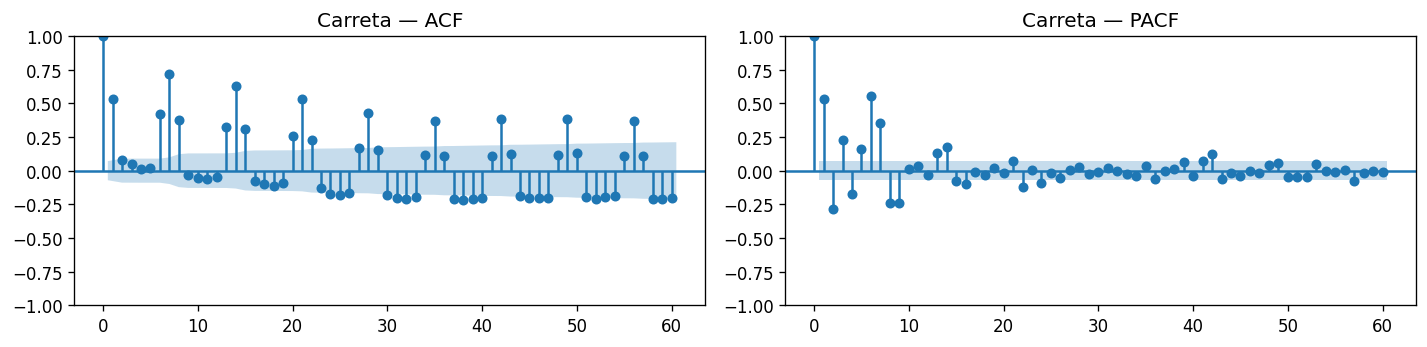

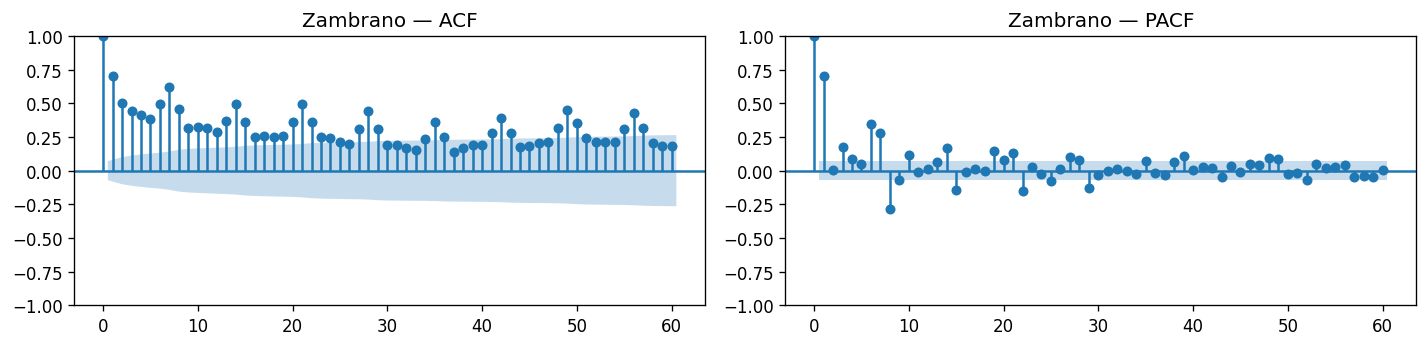

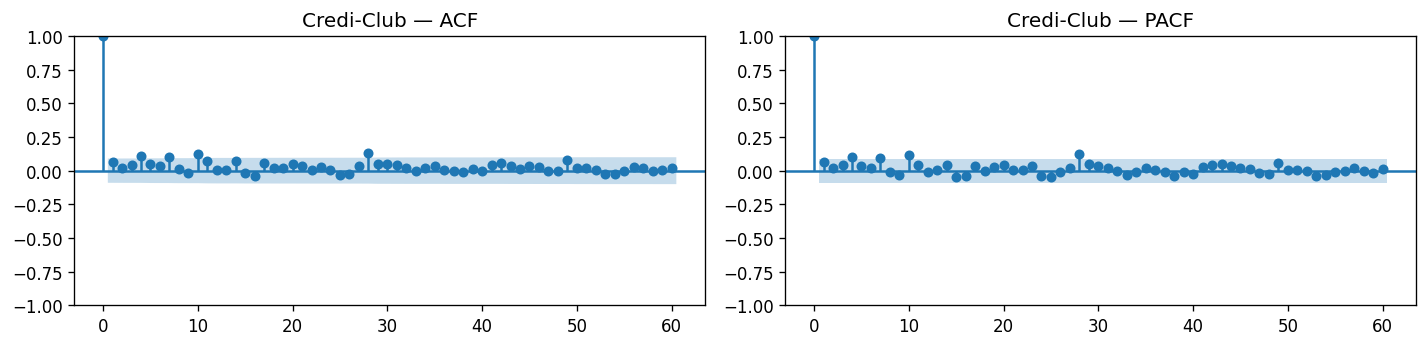

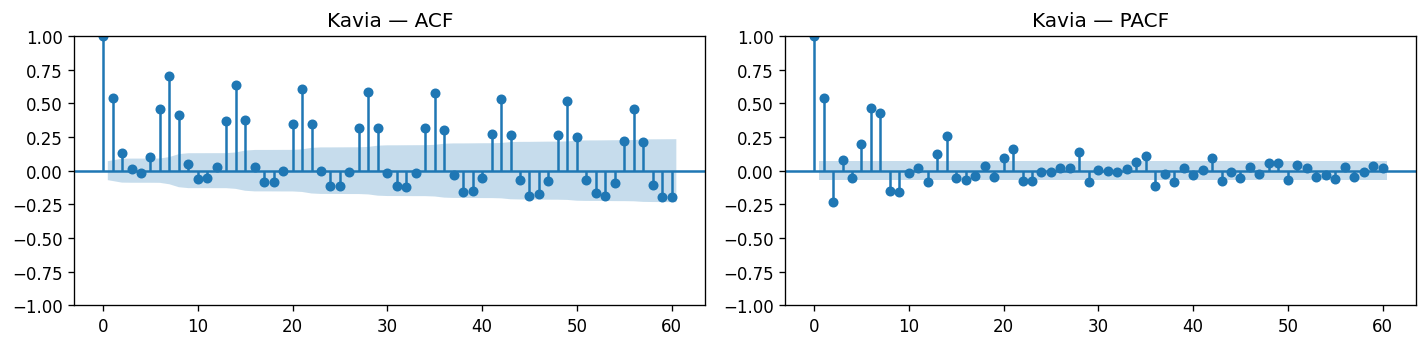

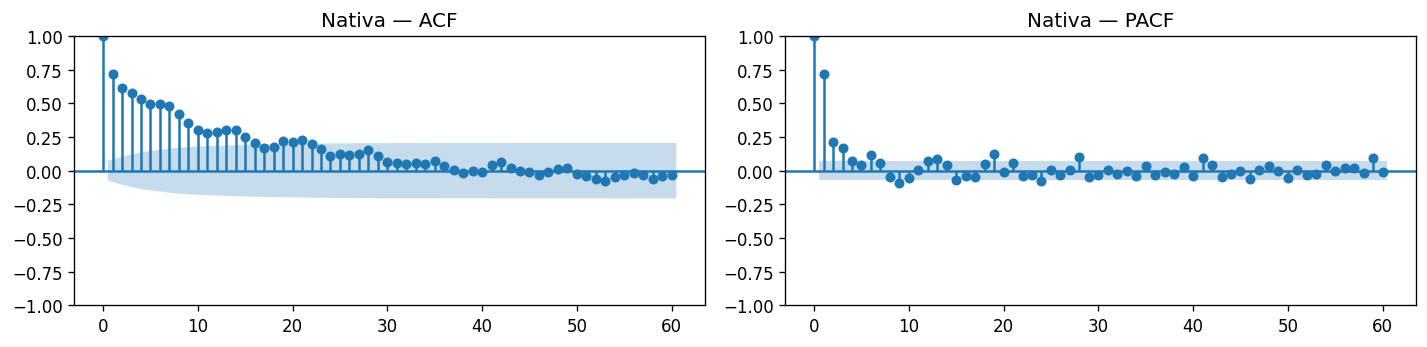

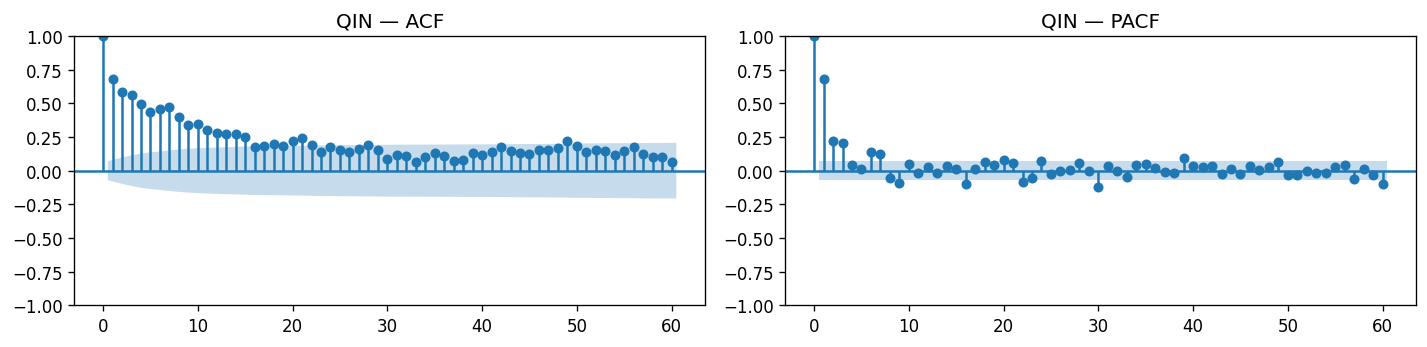

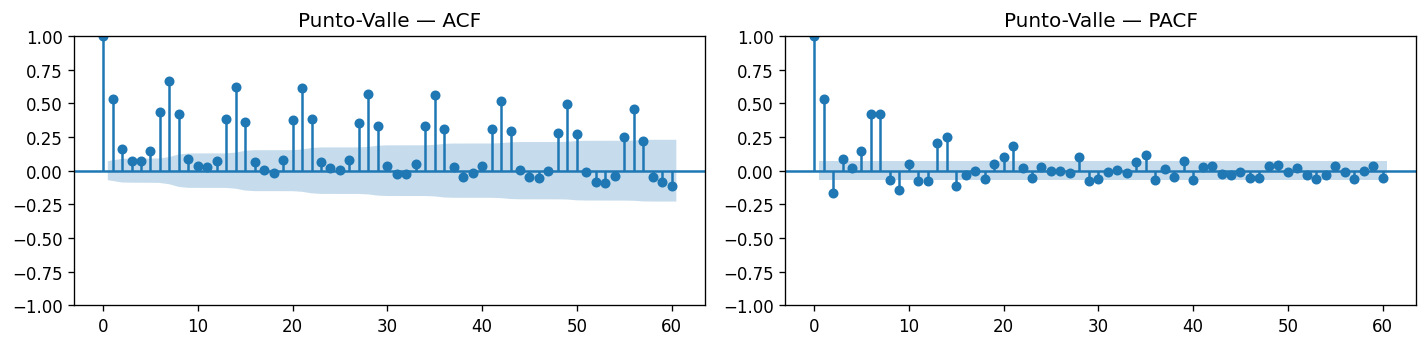

In [24]:
for location, dd in daily_demand.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(dd["demand"],  lags=60, ax=axes[0], title=f"{location} — ACF")
    plot_pacf(dd["demand"], lags=60, ax=axes[1], title=f"{location} — PACF")
    plt.tight_layout()
    plt.show()

In [25]:
# ── Search space ──────────────────────────────────────────────────────────────
p_range = range(0, 3)   # AR order
d_range = range(0, 2)   # differencing
q_range = range(0, 3)   # MA order
P_range = range(0, 2)   # seasonal AR
D_range = range(0, 2)   # seasonal differencing
Q_range = range(0, 2)   # seasonal MA
s       = 7             # weekly seasonality

pdq   = list(itertools.product(p_range, d_range, q_range))
PDQs  = list(itertools.product(P_range, D_range, Q_range, [s]))


def best_sarimax_order(series: pd.Series, exog: pd.Series) -> tuple:
    """Return the (order, seasonal_order) combination with lowest AIC."""
    best_aic, best_order, best_sorder = np.inf, None, None

    for order in pdq:
        for sorder in PDQs:
            try:
                model = SARIMAX(
                    series,
                    exog            = exog,
                    order           = order,
                    seasonal_order  = sorder,
                    enforce_stationarity  = False,
                    enforce_invertibility = False
                )
                res = model.fit(disp=False)
                if res.aic < best_aic:
                    best_aic    = res.aic
                    best_order  = order
                    best_sorder = sorder
            except Exception:
                continue

    return best_order, best_sorder, best_aic


print("Running grid search — this may take a few minutes...")
best_params = {}
for location, dd in daily_demand.items():
    order, sorder, aic = best_sarimax_order(dd["demand"], dd["Avg_Temperature"])
    best_params[location] = {"order": order, "seasonal_order": sorder, "AIC": round(aic, 2)}
    print(f"  {location:15s}  order={order}  seasonal_order={sorder}  AIC={aic:.2f}")

Running grid search — this may take a few minutes...
  Carreta          order=(1, 0, 2)  seasonal_order=(1, 1, 1, 7)  AIC=8382.87
  Zambrano         order=(2, 1, 2)  seasonal_order=(1, 1, 1, 7)  AIC=8251.22
  Credi-Club       order=(0, 1, 2)  seasonal_order=(0, 1, 1, 7)  AIC=5479.88
  Kavia            order=(0, 1, 2)  seasonal_order=(0, 1, 1, 7)  AIC=9408.31
  Nativa           order=(2, 0, 2)  seasonal_order=(0, 1, 1, 7)  AIC=7720.24
  QIN              order=(2, 1, 2)  seasonal_order=(0, 1, 1, 7)  AIC=8504.75
  Punto-Valle      order=(0, 1, 2)  seasonal_order=(0, 1, 1, 7)  AIC=9111.35


In [29]:
TEST_DAYS = 30

fitted_models = {}
results_dict  = {}

for location, dd in daily_demand.items():
    params = best_params[location]

    train = dd.iloc[:-TEST_DAYS]
    test  = dd.iloc[-TEST_DAYS:]

    model = SARIMAX(
        train["demand"],
        exog           = train[["Avg_Temperature"]],
        order          = params["order"],
        seasonal_order = params["seasonal_order"],
        enforce_stationarity  = False,
        enforce_invertibility = False
    )
    res = model.fit(disp=False)

    fitted_models[location] = res
    results_dict[location]  = {"train": train, "test": test, "result": res}

    print(f"{location}: AIC={res.aic:.2f}  BIC={res.bic:.2f}")

Carreta: AIC=7994.00  BIC=8025.99
Zambrano: AIC=7831.18  BIC=7867.72
Credi-Club: AIC=5134.12  BIC=5154.38
Kavia: AIC=8958.19  BIC=8981.13
Nativa: AIC=7378.31  BIC=7409.92
QIN: AIC=8077.31  BIC=8109.41
Punto-Valle: AIC=8652.52  BIC=8675.46



────────────────────────────────────────────────────────────
Carreta
────────────────────────────────────────────────────────────


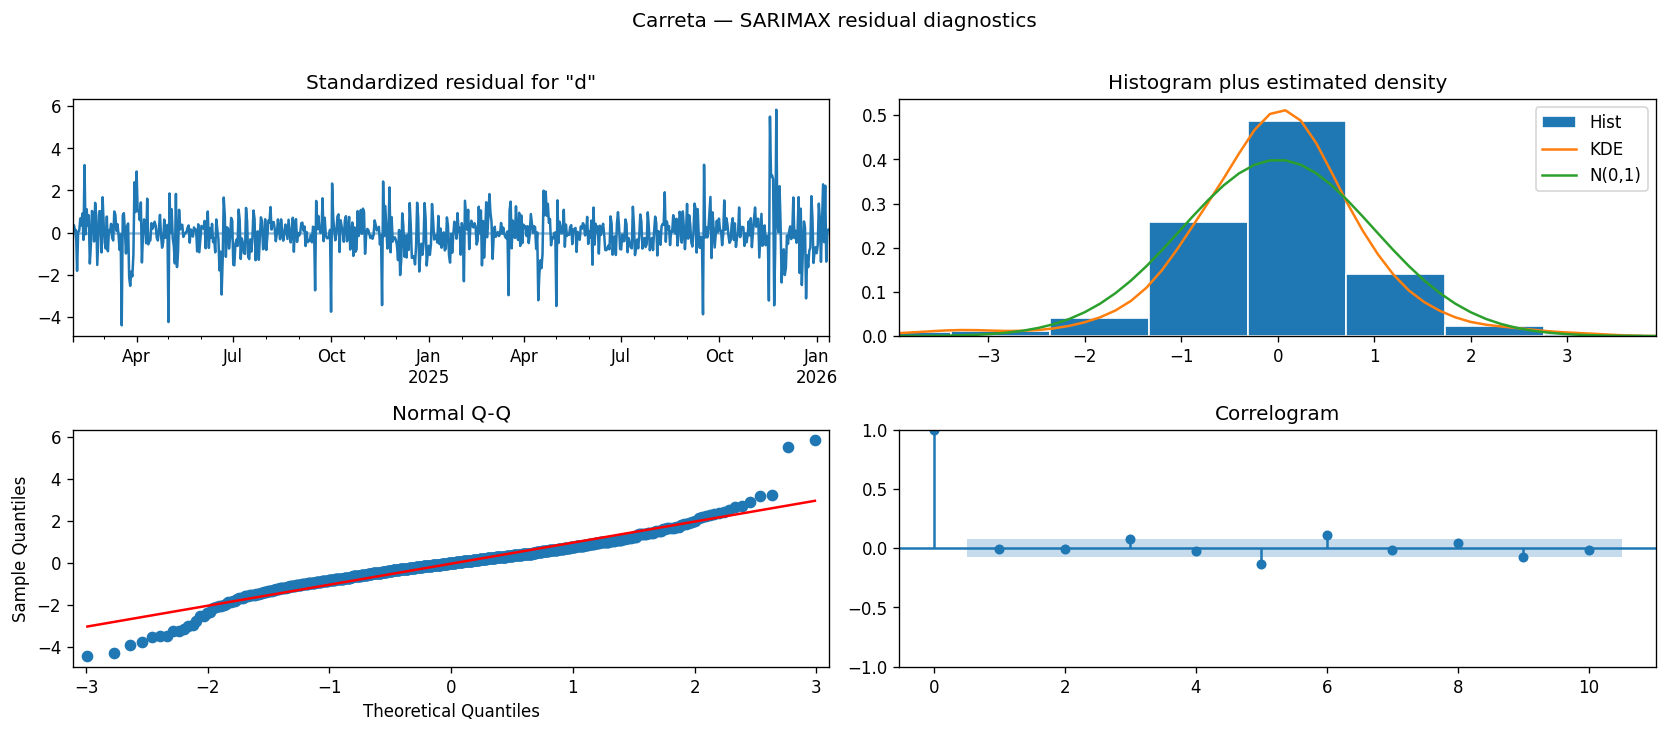


────────────────────────────────────────────────────────────
Zambrano
────────────────────────────────────────────────────────────


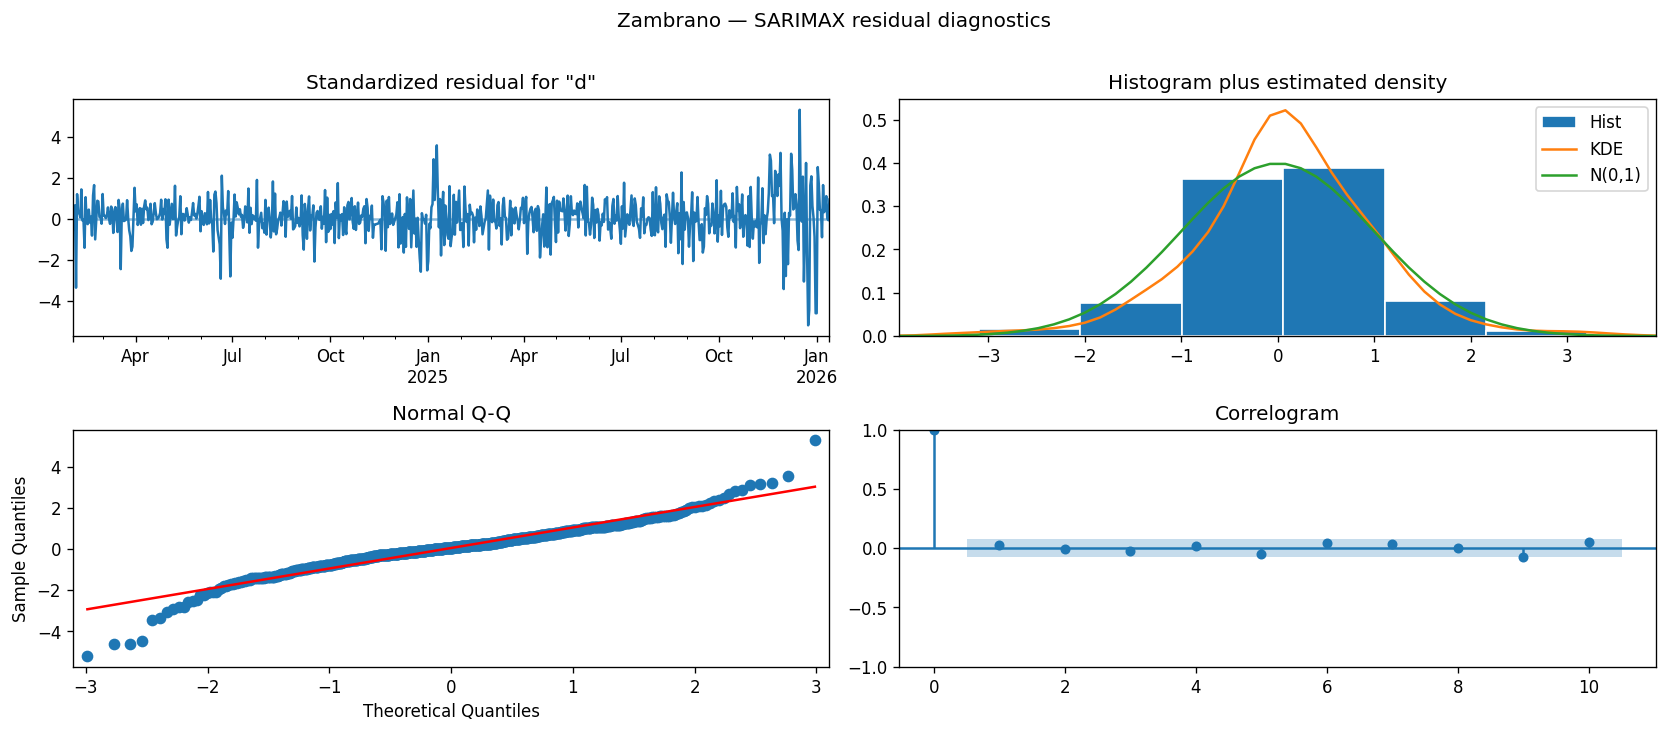


────────────────────────────────────────────────────────────
Credi-Club
────────────────────────────────────────────────────────────


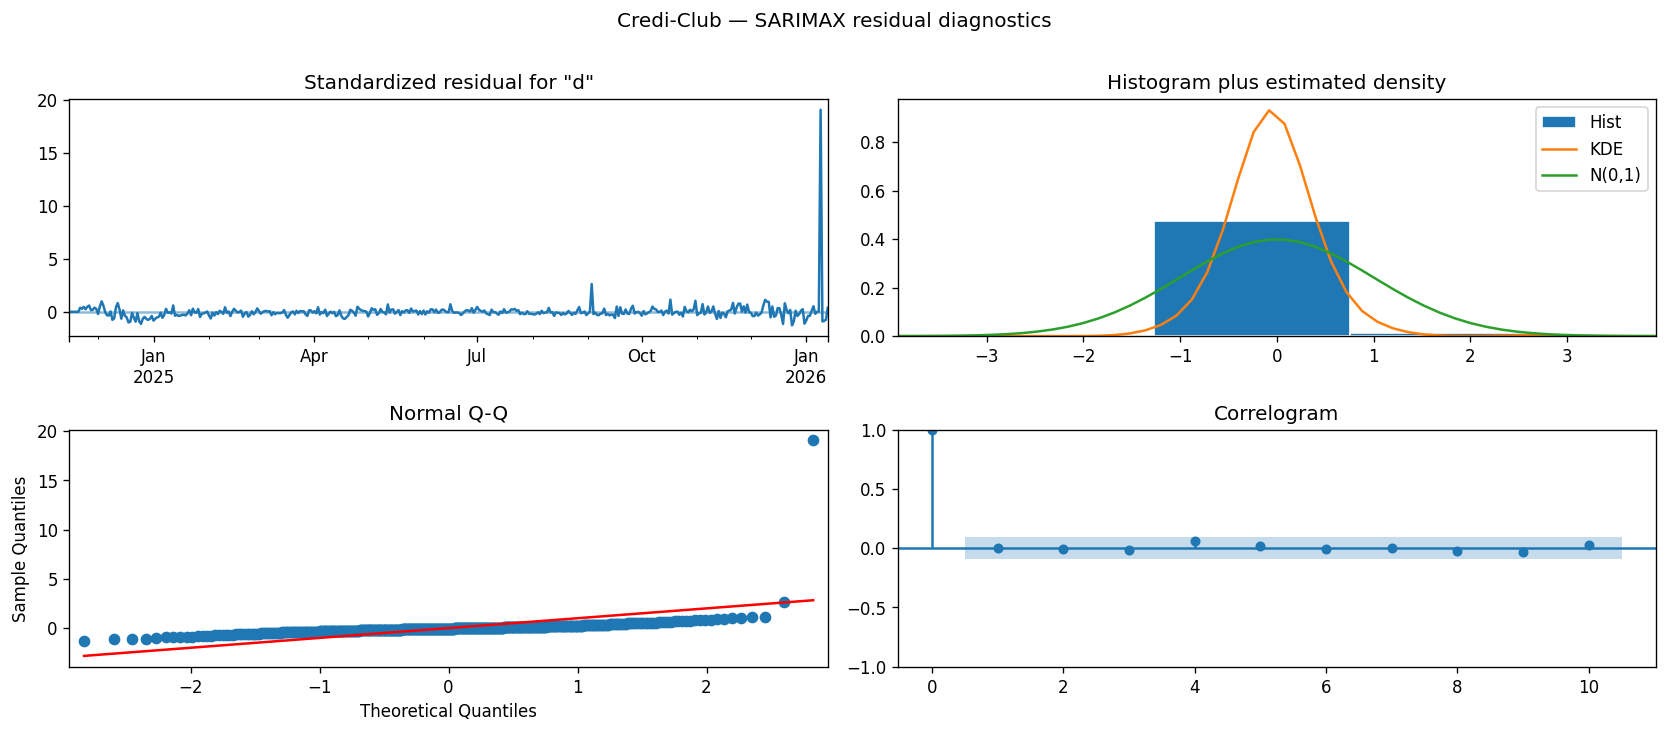


────────────────────────────────────────────────────────────
Kavia
────────────────────────────────────────────────────────────


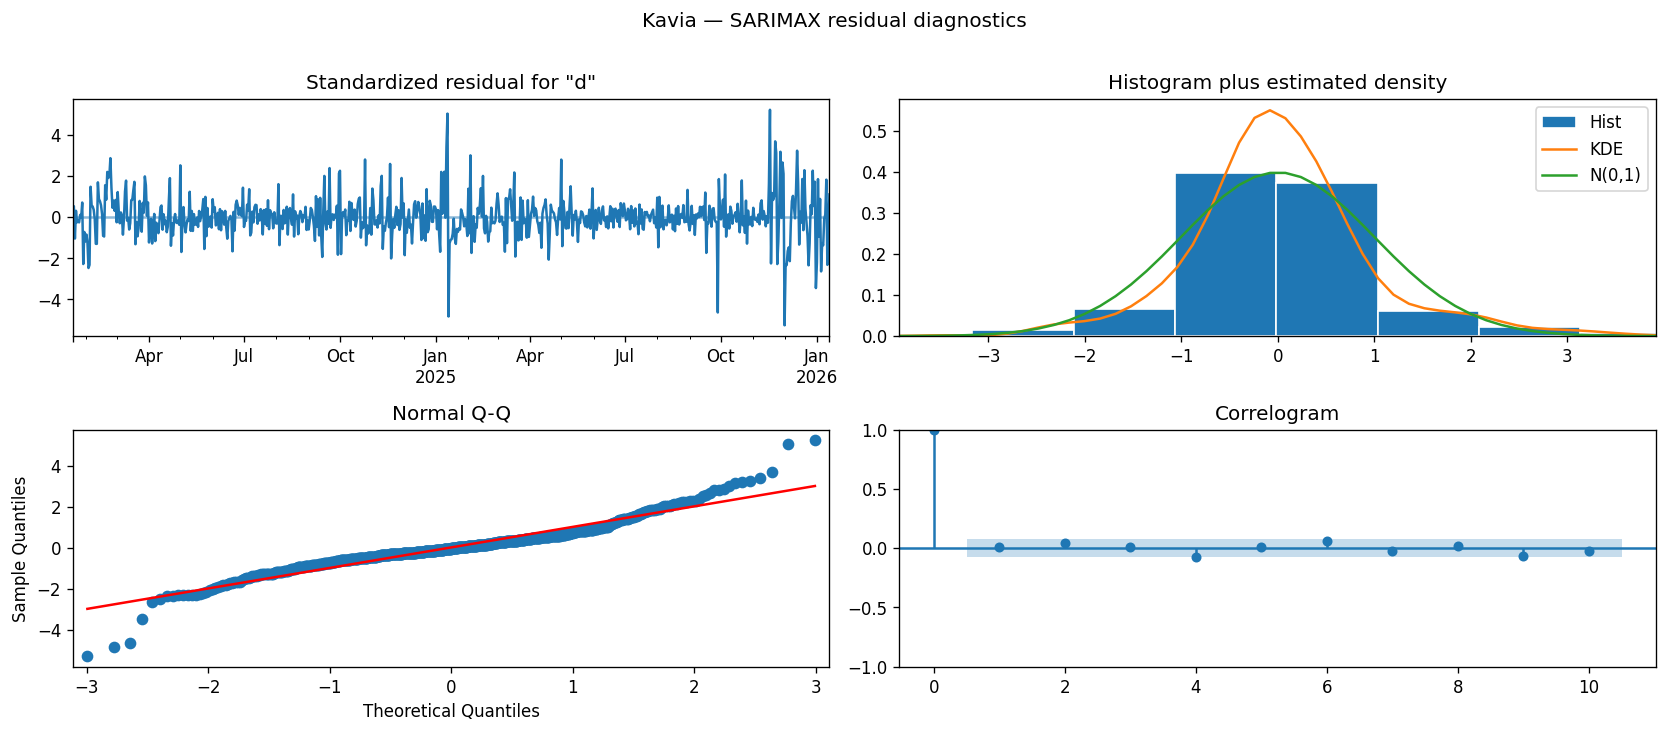


────────────────────────────────────────────────────────────
Nativa
────────────────────────────────────────────────────────────


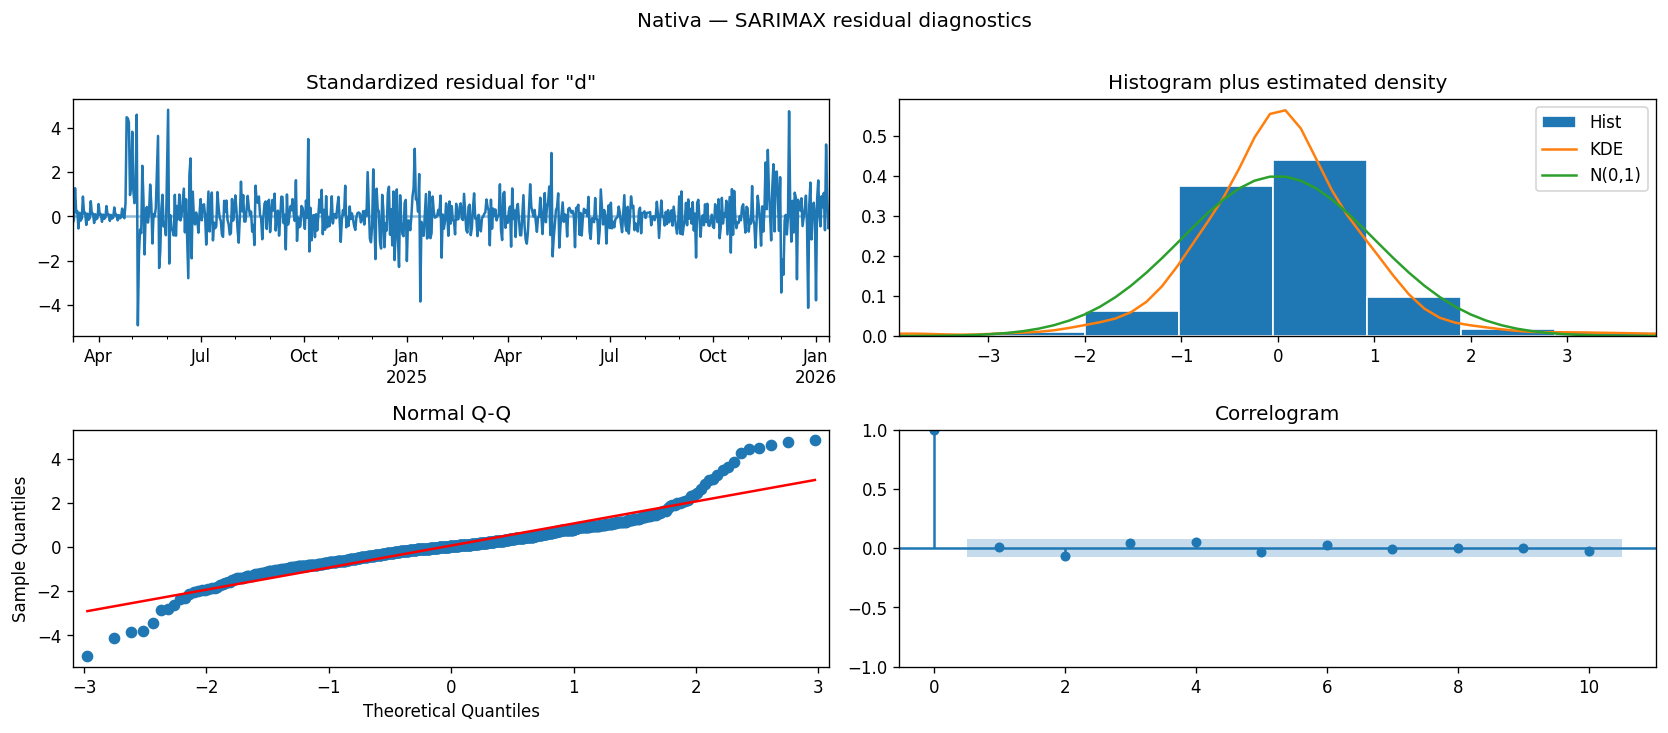


────────────────────────────────────────────────────────────
QIN
────────────────────────────────────────────────────────────


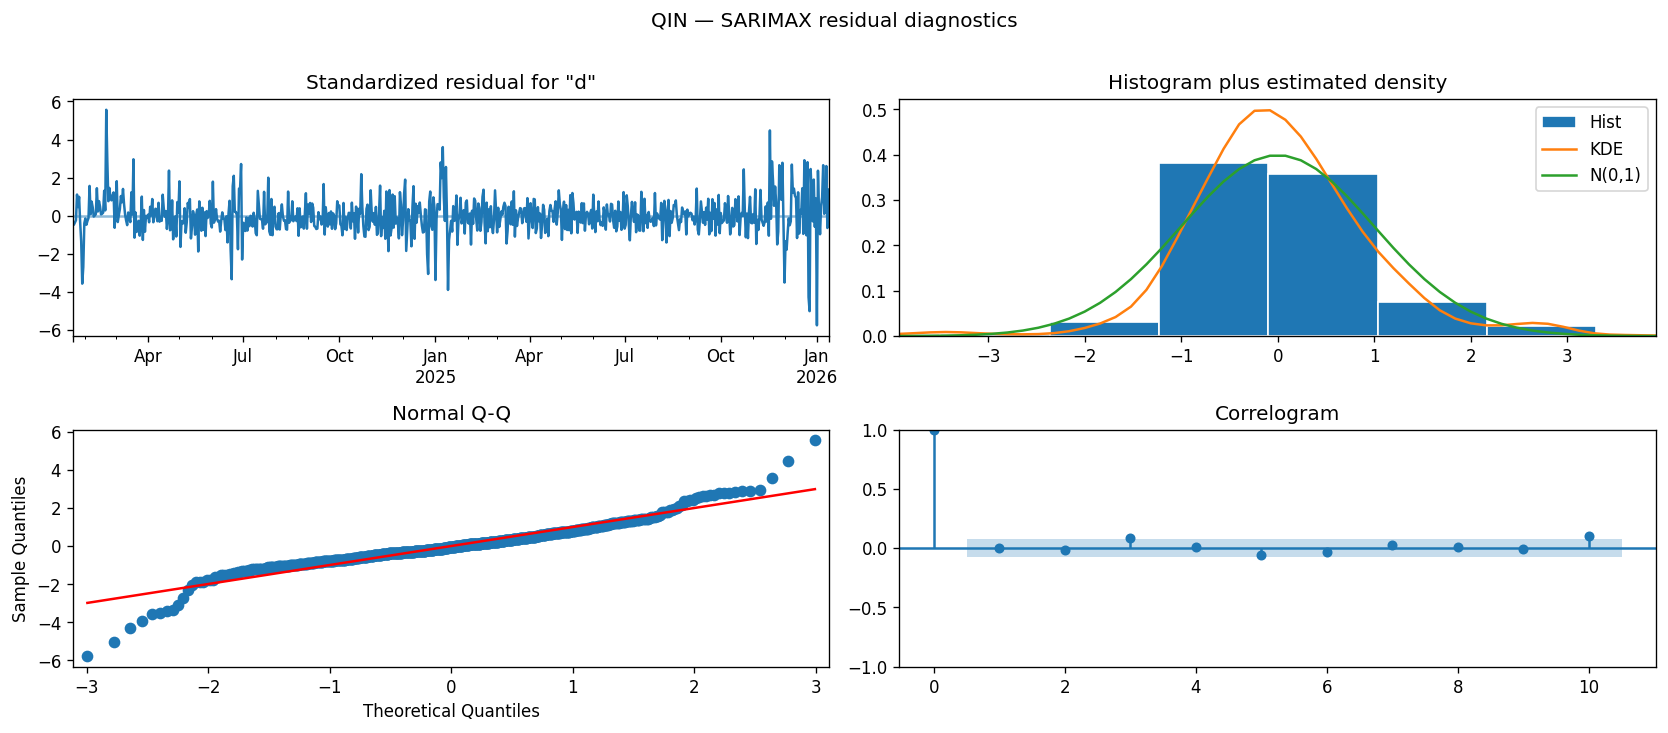


────────────────────────────────────────────────────────────
Punto-Valle
────────────────────────────────────────────────────────────


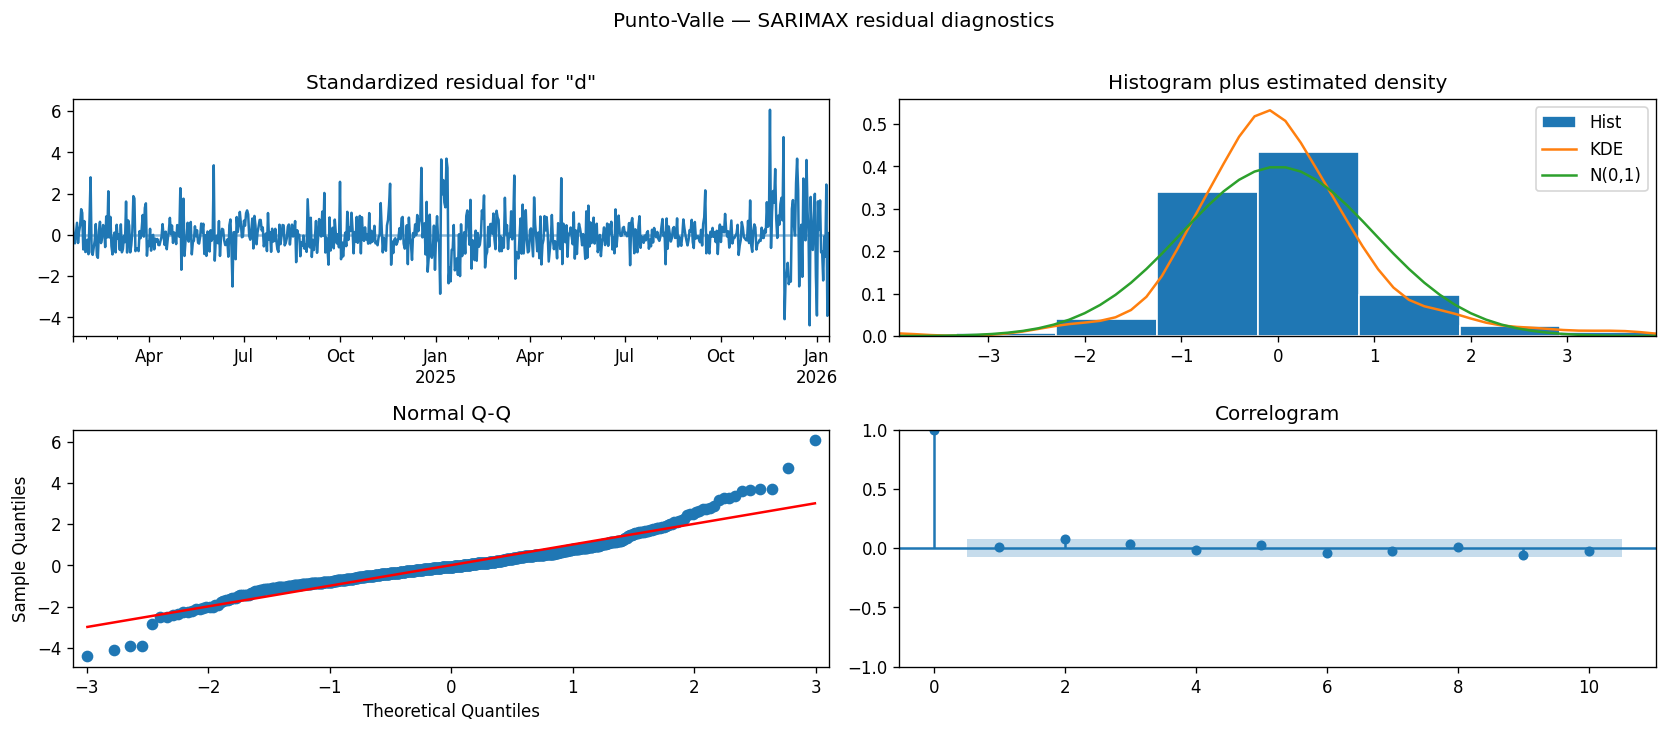

In [30]:
for location, data in results_dict.items():
    print(f"\n{'─'*60}\n{location}\n{'─'*60}")
    data["result"].plot_diagnostics(figsize=(14, 6))
    plt.suptitle(f"{location} — SARIMAX residual diagnostics", y=1.01)
    plt.tight_layout()
    plt.show()

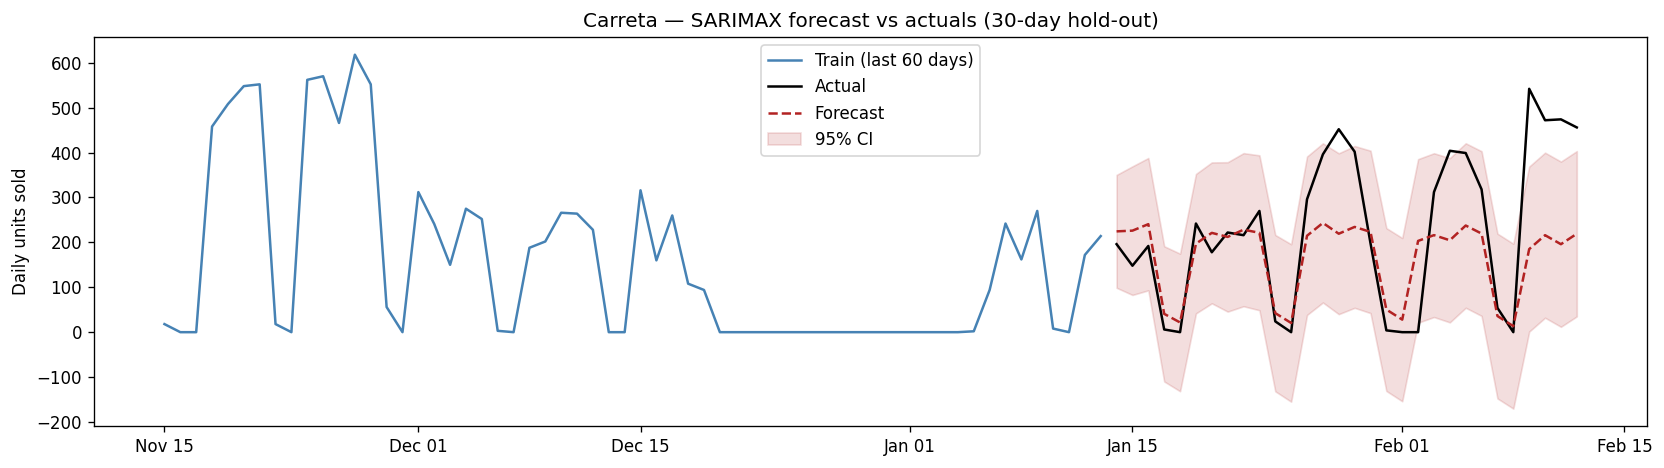

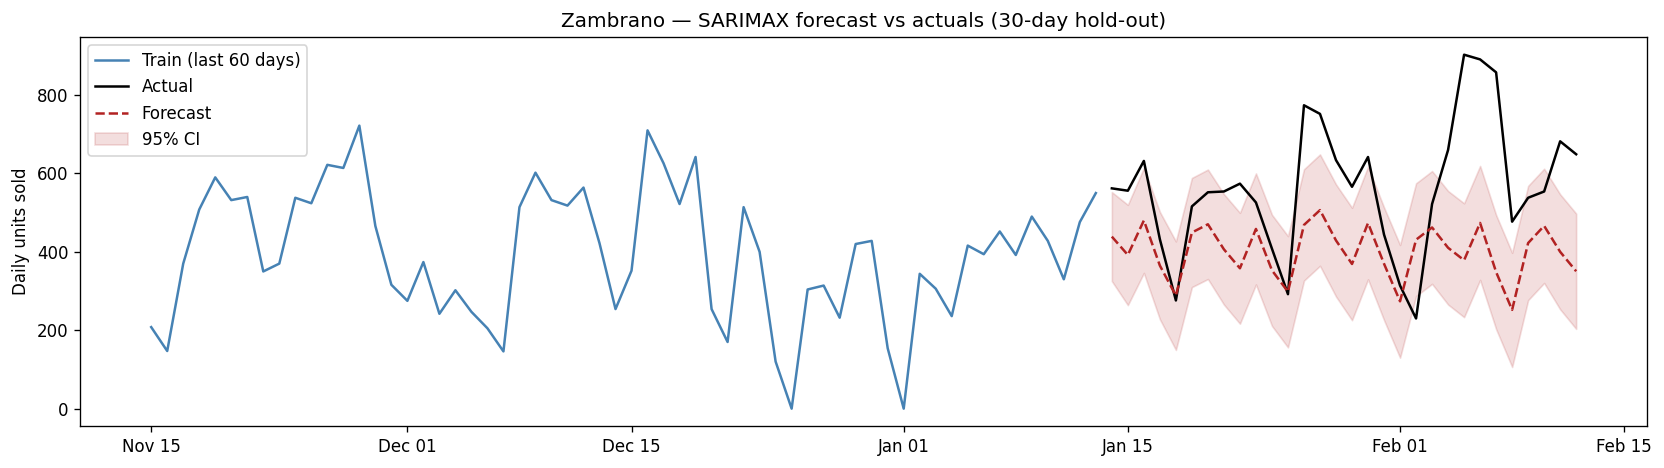

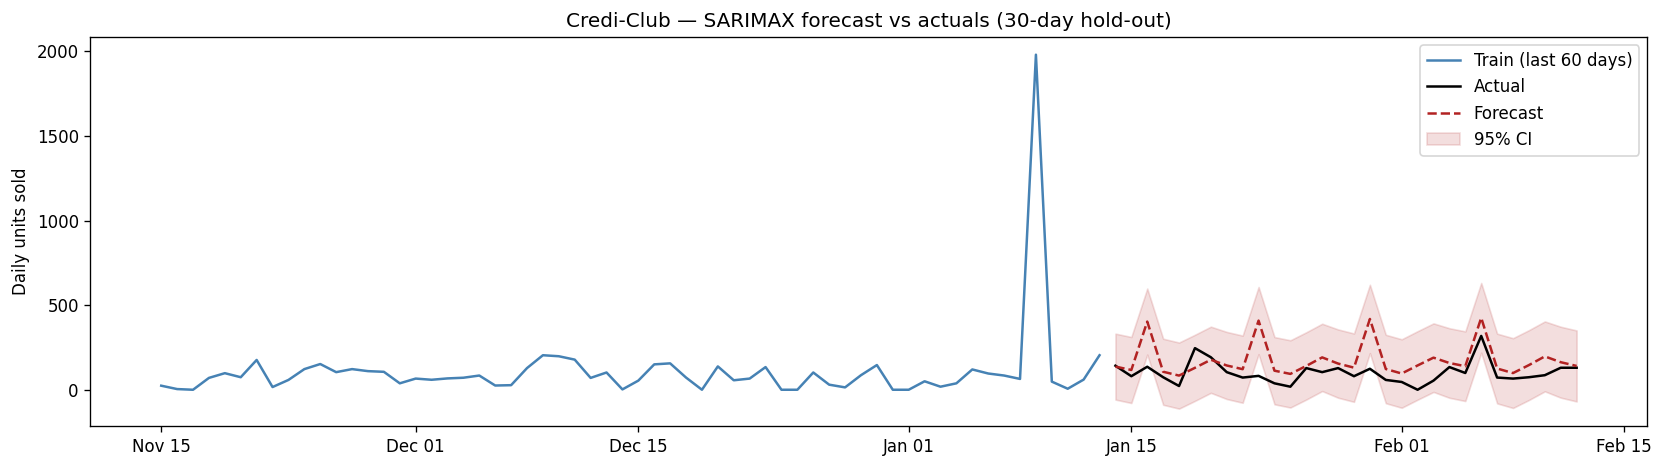

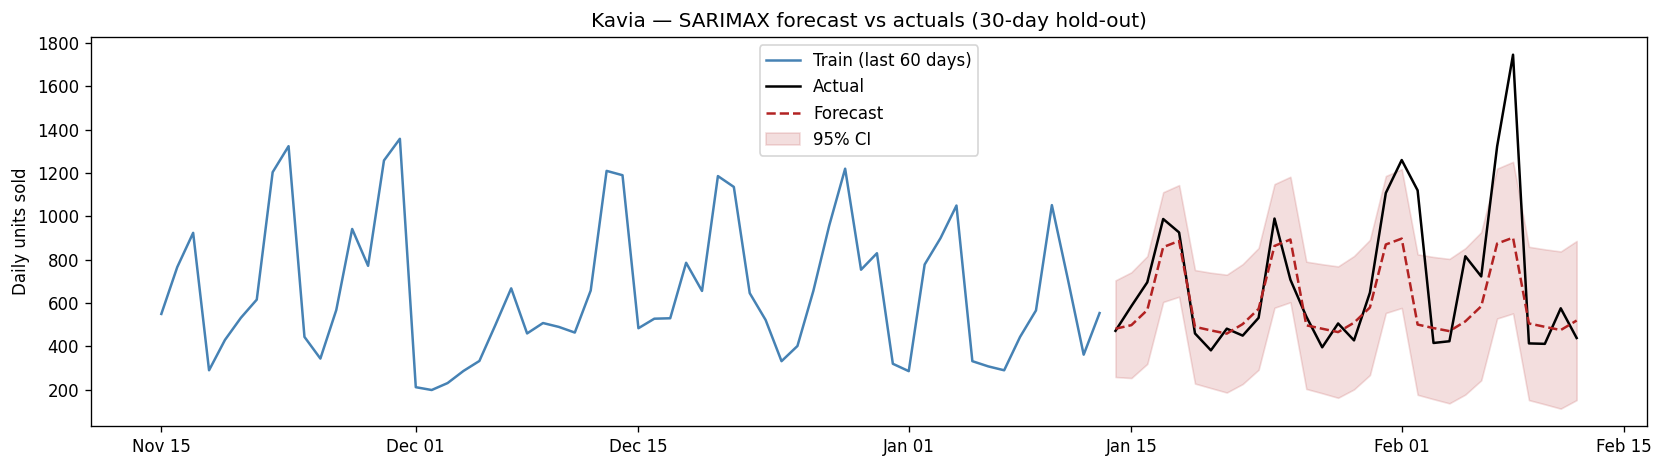

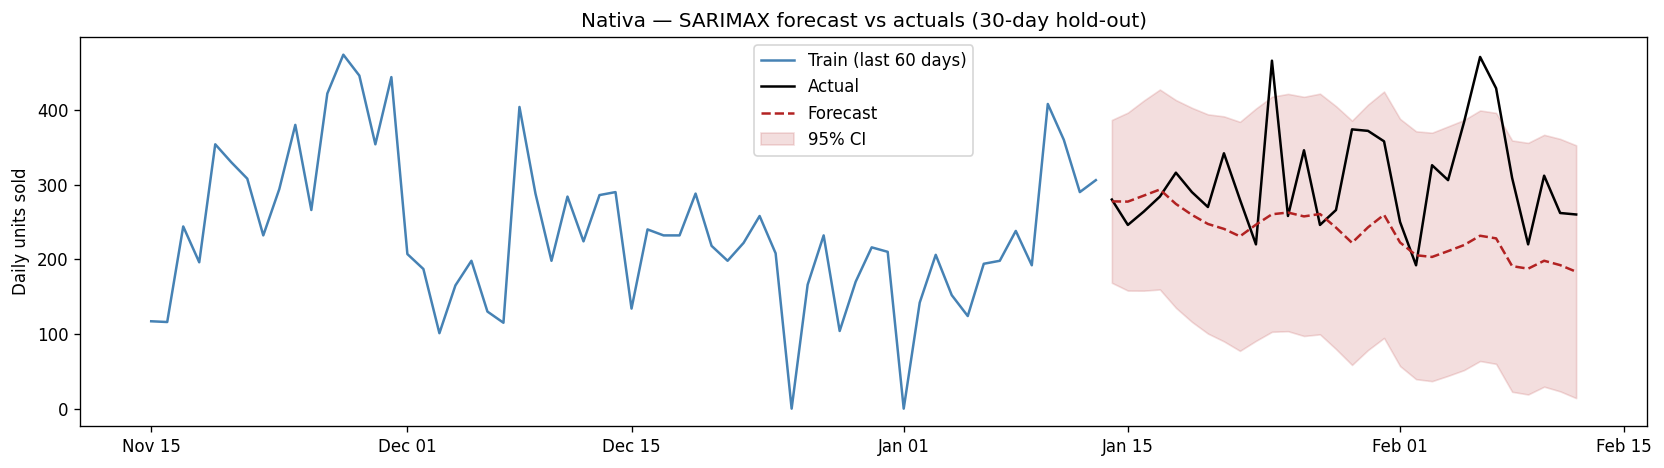

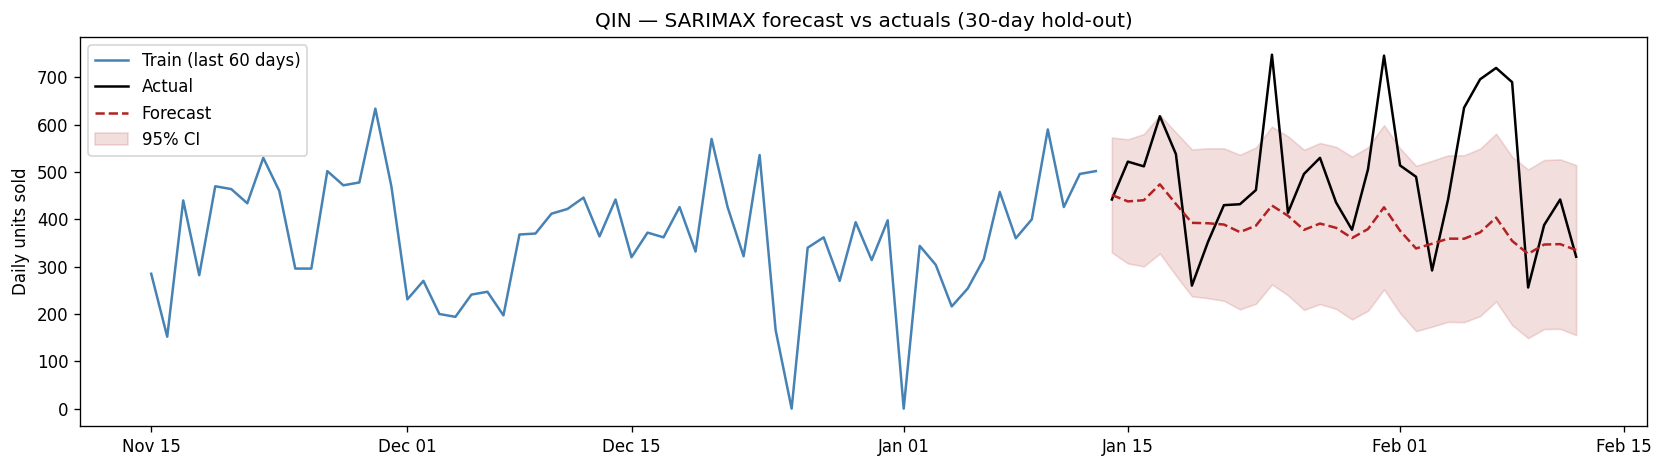

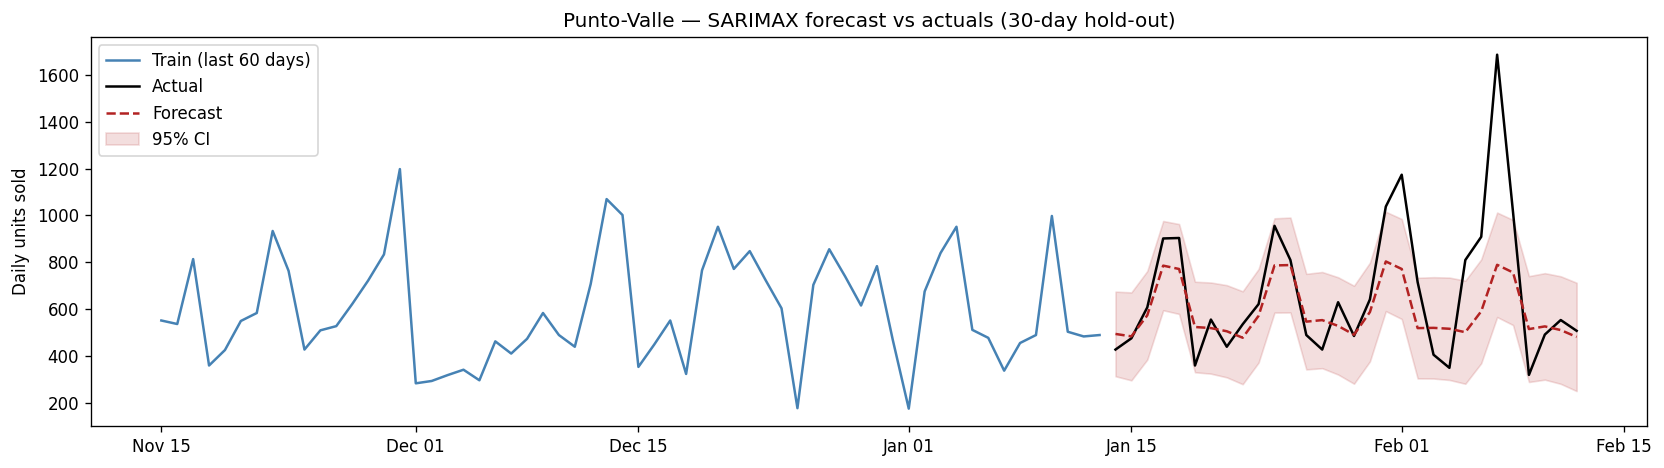

,MAE,RMSE,MAPE %
Branch,,,
Carreta,102.03,139.86,102.76
Zambrano,178.84,222.25,29.45
Credi-Club,81.64,114.45,107.21
Kavia,155.94,242.29,18.72
Nativa,77.60,101.19,22.62
QIN,125.47,162.55,23.28
Punto-Valle,148.57,226.55,20.53


In [31]:
metrics_rows = []

for location, data in results_dict.items():
    train  = data["train"]
    test   = data["test"]
    res    = data["result"]

    # One-step-ahead forecast over the test window
    forecast = res.get_forecast(
        steps = len(test),
        exog  = test[["Avg_Temperature"]]
    )
    fc_mean = forecast.predicted_mean
    fc_ci   = forecast.conf_int(alpha=0.05)

    # Metrics
    mae  = mean_absolute_error(test["demand"], fc_mean)
    rmse = np.sqrt(mean_squared_error(test["demand"], fc_mean))
    mape = np.mean(np.abs((test["demand"] - fc_mean) / test["demand"].replace(0, np.nan))) * 100

    metrics_rows.append({
        "Branch": location,
        "MAE":    round(mae,  2),
        "RMSE":   round(rmse, 2),
        "MAPE %": round(mape, 2)
    })

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(train.index[-60:], train["demand"].iloc[-60:],
            label="Train (last 60 days)", color="steelblue", lw=1.5)
    ax.plot(test.index,  test["demand"],
            label="Actual",   color="black",     lw=1.5)
    ax.plot(fc_mean.index, fc_mean,
            label="Forecast", color="firebrick",  lw=1.5, linestyle="--")
    ax.fill_between(
        fc_ci.index,
        fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
        color="firebrick", alpha=0.15, label="95% CI"
    )

    ax.set_title(f"{location} — SARIMAX forecast vs actuals (30-day hold-out)")
    ax.set_ylabel("Daily units sold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend()
    plt.tight_layout()
    plt.show()

pd.DataFrame(metrics_rows).set_index("Branch")

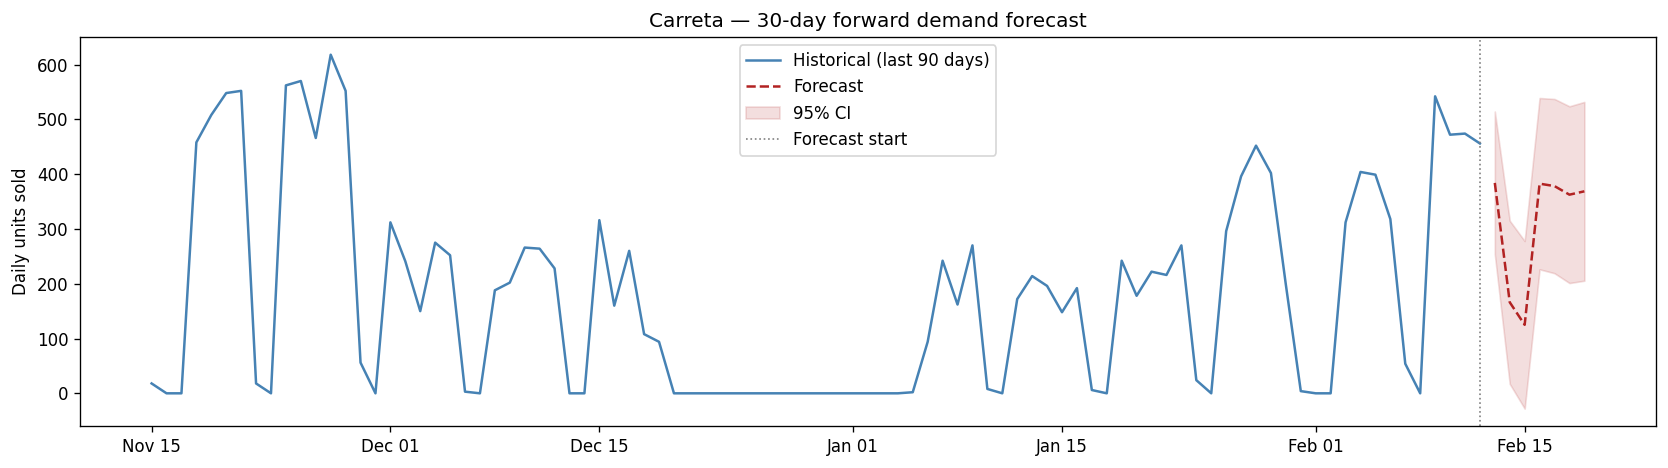


Carreta


,Forecast,Lower 95%,Upper 95%
2026-02-13,384.0,253.6,514.4
2026-02-14,166.2,17.3,315.0
2026-02-15,125.0,-28.0,278.0
2026-02-16,382.6,226.3,538.9
2026-02-17,378.2,219.1,537.2
2026-02-18,362.5,201.2,523.8
2026-02-19,368.7,205.5,531.8


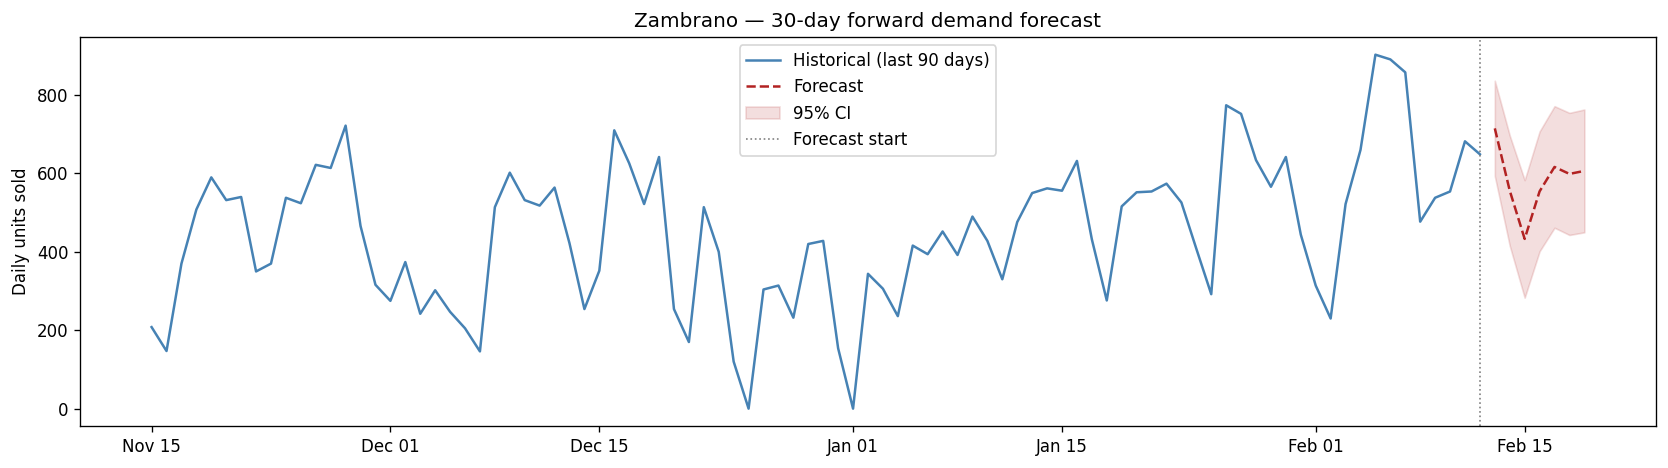


Zambrano


,Forecast,Lower 95%,Upper 95%
2026-02-13,715.0,593.3,836.7
2026-02-14,556.2,415.7,696.8
2026-02-15,433.0,283.0,583.0
2026-02-16,554.3,401.4,707.1
2026-02-17,616.6,461.5,771.7
2026-02-18,598.8,443.1,754.6
2026-02-19,606.5,449.8,763.2


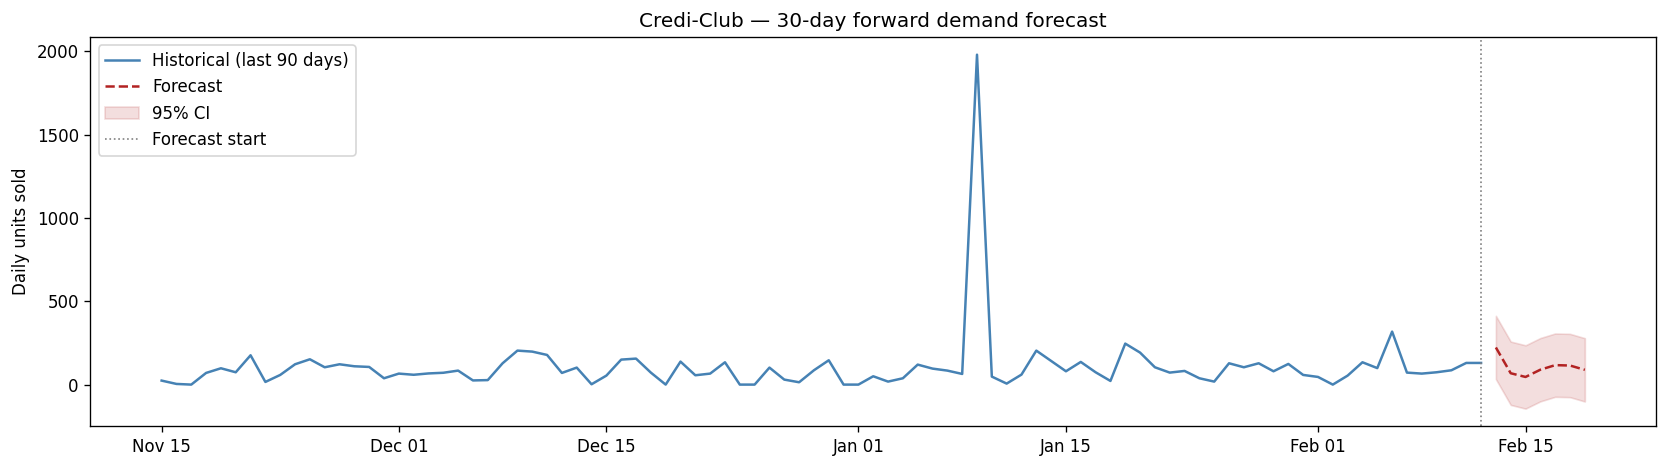


Credi-Club


,Forecast,Lower 95%,Upper 95%
2026-02-13,222.7,32.8,412.7
2026-02-14,68.2,-121.8,258.3
2026-02-15,45.8,-144.3,235.9
2026-02-16,89.4,-100.6,279.5
2026-02-17,116.8,-73.3,306.9
2026-02-18,114.5,-75.5,304.6
2026-02-19,88.6,-101.4,278.7


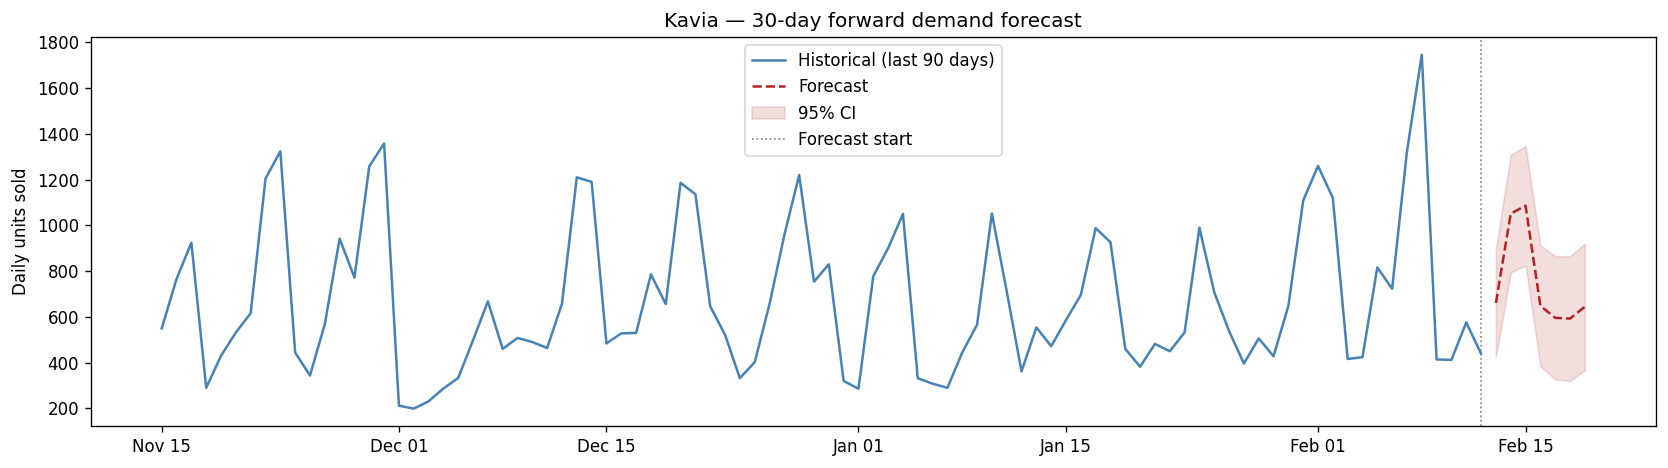


Kavia


,Forecast,Lower 95%,Upper 95%
2026-02-13,661.1,425.6,896.6
2026-02-14,1051.1,794.5,1307.8
2026-02-15,1086.2,825.5,1346.9
2026-02-16,648.7,383.9,913.4
2026-02-17,595.8,327.1,864.5
2026-02-18,592.6,320.0,865.2
2026-02-19,644.4,368.0,920.8


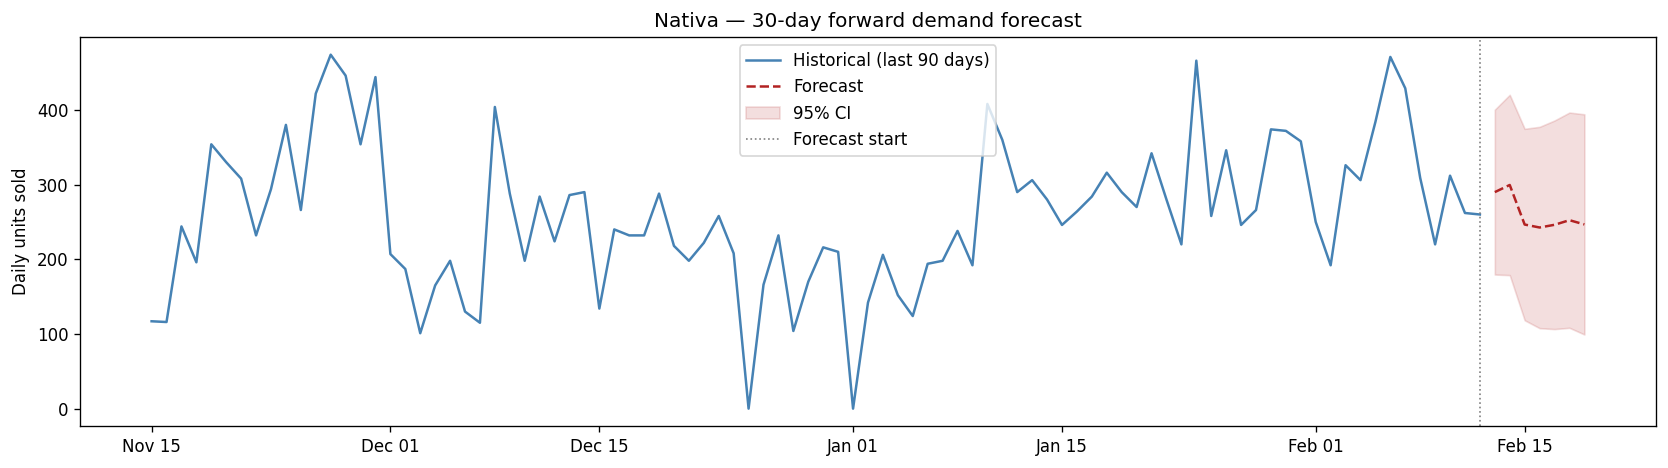


Nativa


,Forecast,Lower 95%,Upper 95%
2026-02-13,290.0,179.6,400.4
2026-02-14,299.5,178.8,420.3
2026-02-15,246.5,118.4,374.7
2026-02-16,242.6,107.8,377.4
2026-02-17,246.2,106.5,385.9
2026-02-18,252.4,108.2,396.5
2026-02-19,246.7,99.3,394.2


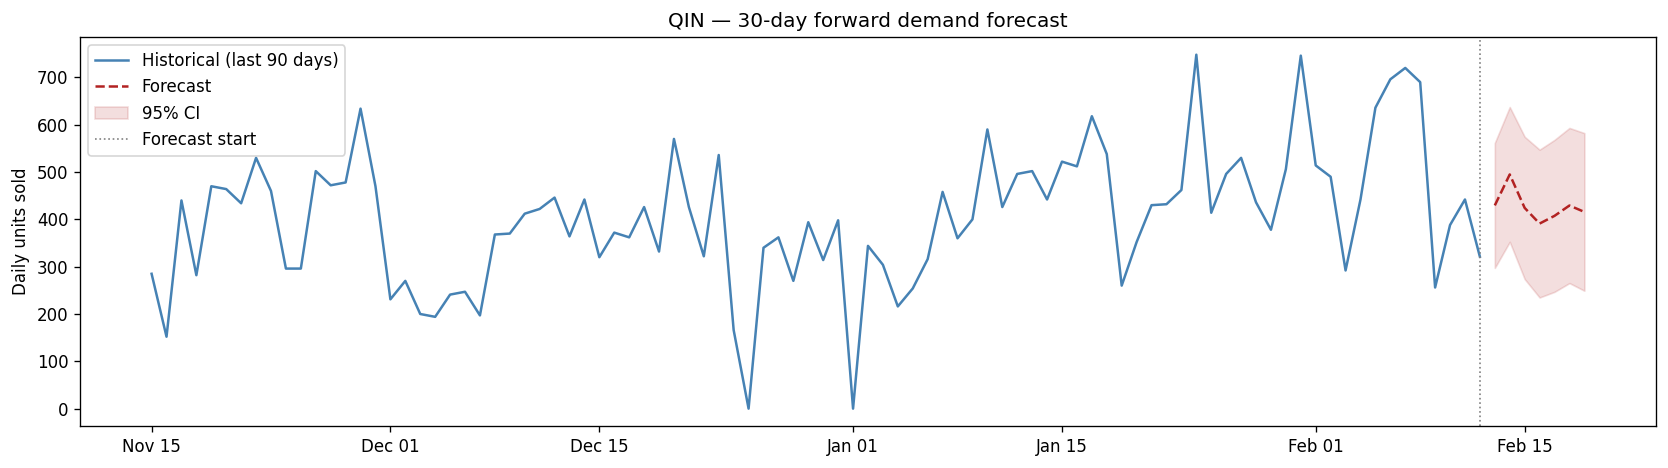


QIN


,Forecast,Lower 95%,Upper 95%
2026-02-13,429.5,297.4,561.6
2026-02-14,495.0,352.5,637.4
2026-02-15,424.2,273.8,574.6
2026-02-16,391.1,234.9,547.3
2026-02-17,407.4,246.8,568.0
2026-02-18,429.3,265.3,593.2
2026-02-19,415.7,249.2,582.3


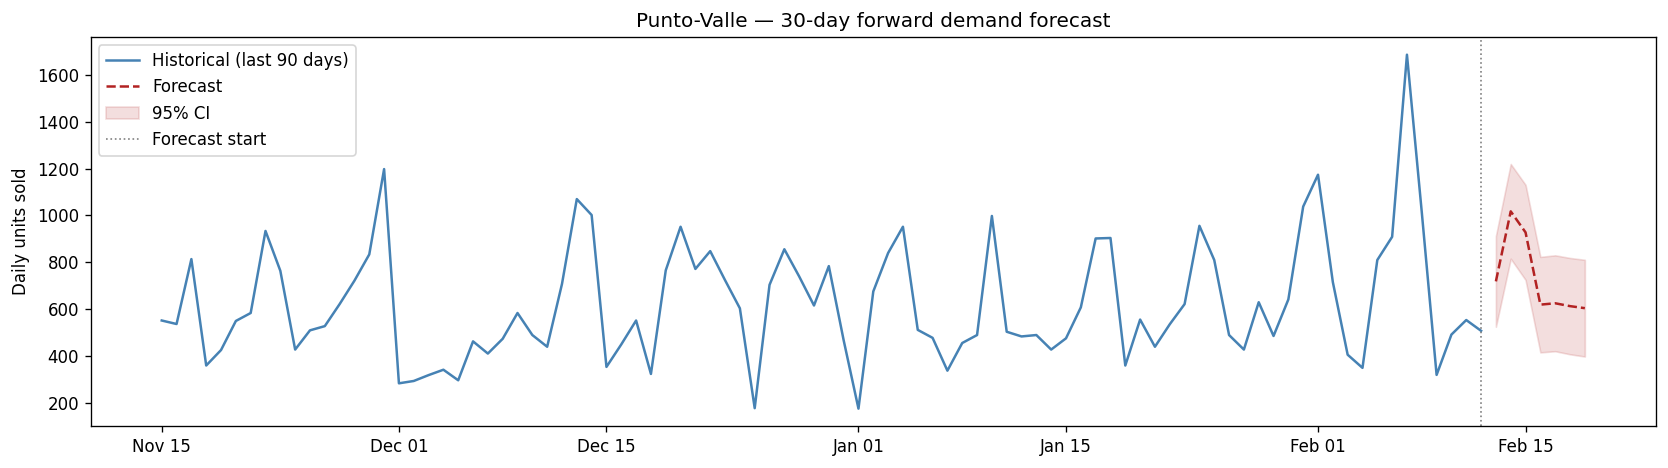


Punto-Valle


,Forecast,Lower 95%,Upper 95%
2026-02-13,718.9,525.2,912.7
2026-02-14,1017.7,815.7,1219.6
2026-02-15,927.9,725.1,1130.8
2026-02-16,619.7,416.0,823.4
2026-02-17,625.5,420.9,830.1
2026-02-18,613.3,407.8,818.8
2026-02-19,604.6,398.3,811.0


In [32]:
FUTURE_DAYS = 7

for location, data in results_dict.items():
    dd  = daily_demand[location]
    res = data["result"]

    # Future date range
    last_date    = dd.index.max()
    future_index = pd.date_range(last_date + pd.Timedelta(days=1), periods=FUTURE_DAYS, freq="D")

    # Proxy temperature: rolling 30-day mean of the same month from training
    future_temp = []
    for d in future_index:
        same_month = dd.loc[dd.index.month == d.month, "Avg_Temperature"]
        future_temp.append(same_month.mean() if len(same_month) else dd["Avg_Temperature"].mean())
    future_exog = pd.DataFrame({"Avg_Temperature": future_temp}, index=future_index)

    # Refit on ALL available data with the best params
    params = best_params[location]
    full_model = SARIMAX(
        dd["demand"],
        exog           = dd[["Avg_Temperature"]],
        order          = params["order"],
        seasonal_order = params["seasonal_order"],
        enforce_stationarity  = False,
        enforce_invertibility = False
    ).fit(disp=False)

    forecast = full_model.get_forecast(steps=FUTURE_DAYS, exog=future_exog)
    fc_mean  = forecast.predicted_mean
    fc_ci    = forecast.conf_int(alpha=0.05)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dd.index[-90:], dd["demand"].iloc[-90:],
            label="Historical (last 90 days)", color="steelblue", lw=1.5)
    ax.plot(fc_mean.index, fc_mean,
            label="Forecast", color="firebrick", lw=1.5, linestyle="--")
    ax.fill_between(
        fc_ci.index,
        fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
        color="firebrick", alpha=0.15, label="95% CI"
    )
    ax.axvline(last_date, color="gray", linestyle=":", lw=1, label="Forecast start")
    ax.set_title(f"{location} — 30-day forward demand forecast")
    ax.set_ylabel("Daily units sold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Print forecast table
    fc_df = pd.DataFrame({
        "Forecast":  fc_mean.round(1),
        "Lower 95%": fc_ci.iloc[:, 0].round(1),
        "Upper 95%": fc_ci.iloc[:, 1].round(1)
    })
    print(f"\n{location}")
    display(fc_df)